In [2]:
from pathlib import Path  # filesystem paths
from typing import Dict, List  # type hints for mappings and lists

import numpy as np  # numerical arrays and math utilities
import pandas as pd  # tabular data handling
import matplotlib.pyplot as plt  # plotting interface
import seaborn as sns  # statistical visualization helpers

from sklearn.linear_model import LinearRegression  # linear baseline regressor
from sklearn.ensemble import RandomForestRegressor  # tree-based ensemble regressor
from sklearn.model_selection import train_test_split, cross_val_score  # split and CV helpers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # regression metrics


In [3]:
PROJECT_ROOT = Path().resolve().parent  # repo root (one level up)
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"  # processed feature matrices
REPORTS_DIR = PROJECT_ROOT / "reports"  # reports directory
PLOTS_DIR = REPORTS_DIR / "Models" / "Regression"  # plot output directory
PLOTS_DIR.mkdir(parents=True, exist_ok=True)  # ensure plot folder exists


In [4]:
def load_processed(dataset: str) -> pd.DataFrame:  # read processed dataset by key
    filename = f"processed_{dataset}.csv"  # build filename
    path = PROCESSED_DATA_DIR / filename  # build full path
    if not path.exists():  # validate file presence
        raise FileNotFoundError(f"File not found: {path}")  # informative error
    return pd.read_csv(path)  # load CSV into DataFrame


In [5]:
def get_models() -> Dict[str, object]:  # return regression models to evaluate
    models: Dict[str, object] = {
        "LinearRegression": LinearRegression(n_jobs=-1),  # linear baseline
        "RandomForestRegressor": RandomForestRegressor(
            n_estimators=300,  # number of trees
            random_state=42,  # reproducibility
            n_jobs=-1,  # use all cores
        ),
    }

    # Try to add XGBRegressor if installed
    try:
        from xgboost import XGBRegressor  # optional boosted trees

        models["XGBRegressor"] = XGBRegressor(
            n_estimators=400,  # trees in ensemble
            max_depth=4,  # tree depth
            learning_rate=0.05,  # shrinkage rate
            subsample=0.9,  # row subsampling
            colsample_bytree=0.9,  # column subsampling
            random_state=42,  # reproducibility
            n_jobs=-1,  # all cores
        )
    except ImportError:
        print("⚠ xgboost is not installed. Skipping XGBRegressor.")  # log missing dep

    return models  # return model dict


In [6]:
def train_single_model(
    df: pd.DataFrame,  # processed dataset
    model_name: str,  # model identifier
    model,  # estimator instance
    dataset_name: str,  # dataset tag
    drop_g1_g2: bool = False,  # optionally drop G1/G2 features
    test_size: float = 0.2,  # test split ratio
    random_state: int = 42,  # RNG seed
) -> Dict:
    if "G3" not in df.columns:  # ensure target present
        raise ValueError("Column G3 was not found in dataframe.")  # guard missing target

    y = df["G3"]  # target vector
    feature_cols: List[str] = [c for c in df.columns if c != "G3"]  # candidate features

    if drop_g1_g2:  # scenario: remove earlier grades
        feature_cols = [c for c in feature_cols if c not in ("G1", "G2")]  # drop G1/G2

    X = df[feature_cols]  # feature matrix

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
    )  # train/test split

    model.fit(X_train, y_train)  # fit model
    y_pred = model.predict(X_test)  # predict on test

    mae = mean_absolute_error(y_test, y_pred)  # MAE metric
    rmse = mean_squared_error(y_test, y_pred) ** 0.5  # RMSE metric
    r2 = r2_score(y_test, y_pred)  # R-squared metric

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )  # cross-validation RMSE (negative)
    cv_rmse = -cv_scores  # make RMSE positive

    result = {
        "dataset": dataset_name,  # dataset name
        "scenario": "with_G1_G2" if not drop_g1_g2 else "without_G1_G2",  # scenario label
        "model": model_name,  # model name
        "n_features": X.shape[1],  # feature count
        "MAE": mae,  # MAE score
        "RMSE": rmse,  # RMSE score
        "R2": r2,  # R-squared score
        "CV_RMSE_mean": cv_rmse.mean(),  # CV mean RMSE
        "CV_RMSE_std": cv_rmse.std(),  # CV std RMSE
        "y_test": y_test.values,  # true targets
        "y_pred": y_pred,  # predicted targets
    }  # packaged metrics/results

    return result  # return run result


In [7]:
def plot_predictions_vs_truth(result: Dict, save_dir: Path) -> None:  # plot predicted vs true
    y_test = result["y_test"]  # ground-truth values
    y_pred = result["y_pred"]  # predicted values

    plt.figure(figsize=(6, 6))  # new square figure
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)  # scatter of truth vs pred
    plt.plot(
        [y_test.min(), y_test.max()],  # x diagonal endpoints
        [y_test.min(), y_test.max()],  # y diagonal endpoints
        color="red",  # line color
        linestyle="--",  # dashed line
        label="Ideal",  # legend label
    )
    plt.xlabel("True G3")  # x label
    plt.ylabel("Predicted G3")  # y label
    plt.title(
        f"{result['dataset']} | {result['scenario']} | {result['model']}\n"
        "Predicted vs True G3"
    )  # plot title
    plt.legend()  # show legend
    plt.tight_layout()  # tidy layout

    filename = (
        f"{result['dataset']}_{result['scenario']}_{result['model']}_pred_vs_true.png"
        .replace(" ", "_")
    )  # build filename
    plt.savefig(save_dir / filename, dpi=300, bbox_inches="tight")  # save plot

    plt.show()  # display plot


In [8]:
def plot_residuals(result: Dict, save_dir: Path) -> None:  # plot residual distribution
    y_test = result["y_test"]  # ground truth
    y_pred = result["y_pred"]  # predictions
    residuals = y_test - y_pred  # residuals vector

    plt.figure(figsize=(7, 4))  # new figure
    sns.histplot(residuals, bins=20, kde=True)  # histogram + KDE
    plt.xlabel("Residual (True - Predicted)")  # x label
    plt.title(
        f"{result['dataset']} | {result['scenario']} | {result['model']}\n"
        "Residual Distribution"
    )  # title
    plt.tight_layout()  # tidy layout

    filename = (
        f"{result['dataset']}_{result['scenario']}_{result['model']}_residuals.png"
        .replace(" ", "_")
    )  # filename
    plt.savefig(save_dir / filename, dpi=300, bbox_inches="tight")  # save plot

    plt.show()  # display plot


In [9]:
def plot_summary_tables_and_charts(results_df: pd.DataFrame, save_dir: Path) -> None:  # summary tables/plots
    summary_cols = [
        "dataset", "scenario", "model",  # identifiers
        "n_features", "MAE", "RMSE", "R2",  # metrics
        "CV_RMSE_mean", "CV_RMSE_std",  # CV stats
    ]  # columns to retain

    summary = results_df[summary_cols].round(3)  # rounded summary table

    print("\n===== Regression Results Summary =====\n")  # heading
    # print(summary.to_string(index=False))  # console table

    try:
        from IPython.display import display  # notebook display helper
        display(summary)  # show formatted table
    except ImportError:
        pass  # ignore outside notebooks

    summary.to_csv(save_dir / "regression_results_summary.csv", index=False)  # save CSV

    plt.figure(figsize=(10, 6))  # RMSE plot figure
    sns.barplot(
        data=results_df,
        x="model",
        y="RMSE",
        hue="scenario",
    )  # RMSE bars
    plt.title("Comparison of RMSE by Model and Scenario")  # title
    plt.ylabel("RMSE")  # y label
    plt.tight_layout()  # layout
    plt.savefig(save_dir / "rmse_comparison.png", dpi=300, bbox_inches="tight")  # save plot
    plt.show()  # display

    plt.figure(figsize=(10, 6))  # R2 plot figure
    sns.barplot(
        data=results_df,
        x="model",
        y="R2",
        hue="scenario",
    )  # R2 bars
    plt.title("Comparison of R² by Model and Scenario")  # title
    plt.ylabel("R²")  # y label
    plt.tight_layout()  # layout
    plt.savefig(save_dir / "r2_comparison.png", dpi=300, bbox_inches="tight")  # save plot
    plt.show()  # display



### Dataset: mat ###

  > Scenario: with_G1_G2
    - Training LinearRegression ...


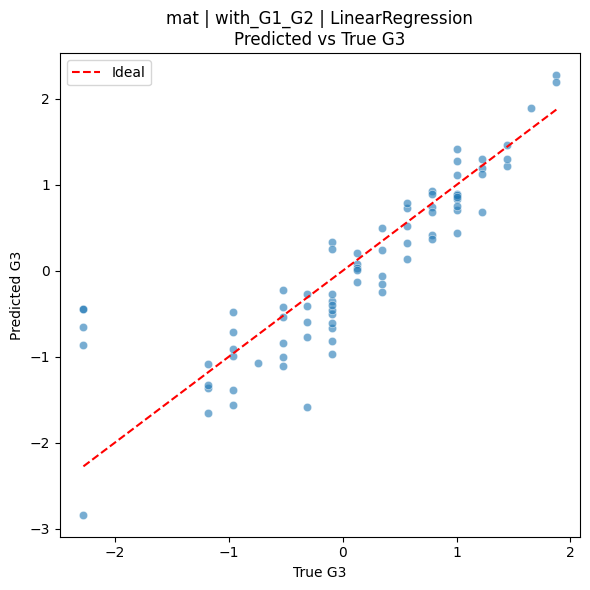

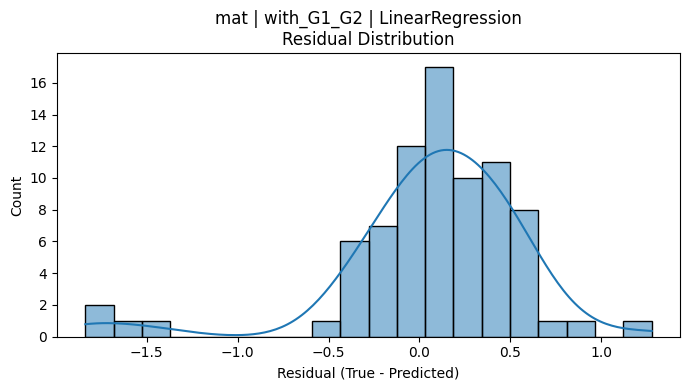

    - Training RandomForestRegressor ...


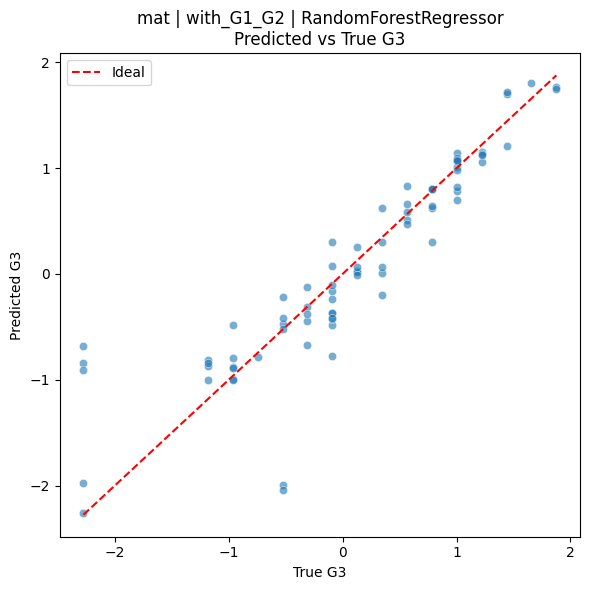

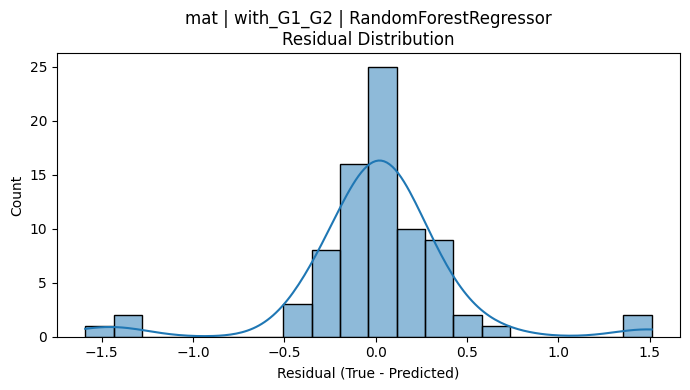

    - Training XGBRegressor ...


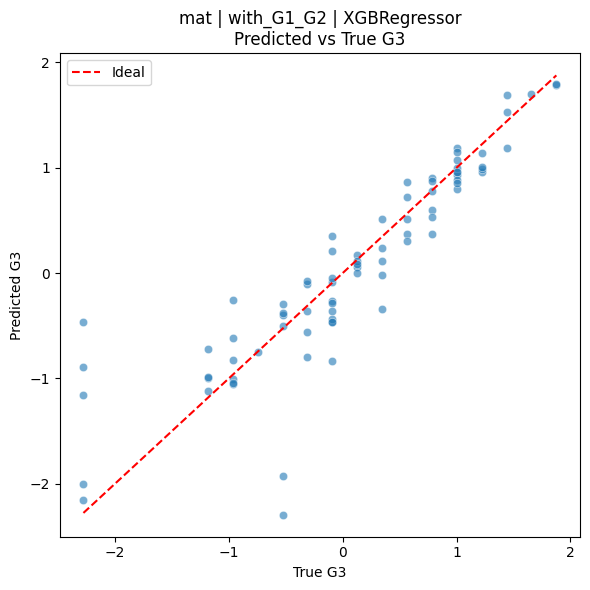

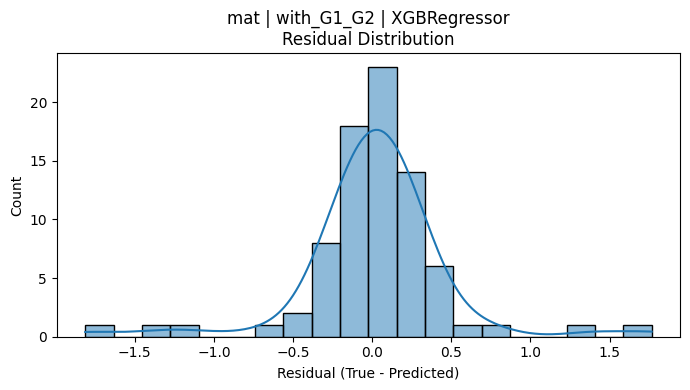


  > Scenario: without_G1_G2
    - Training LinearRegression ...


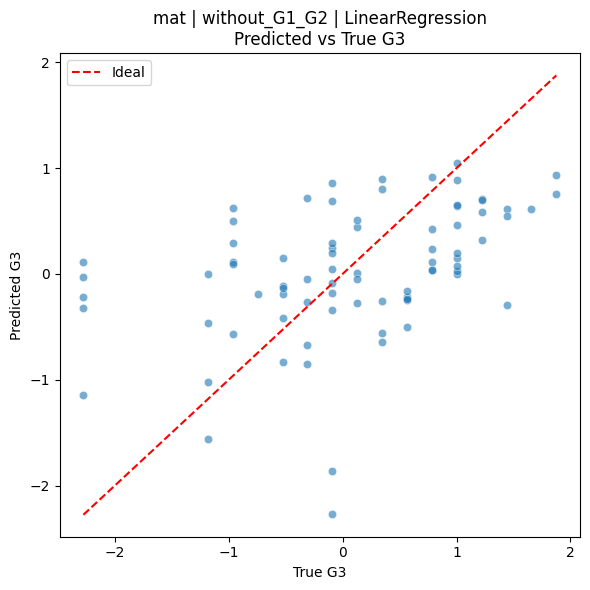

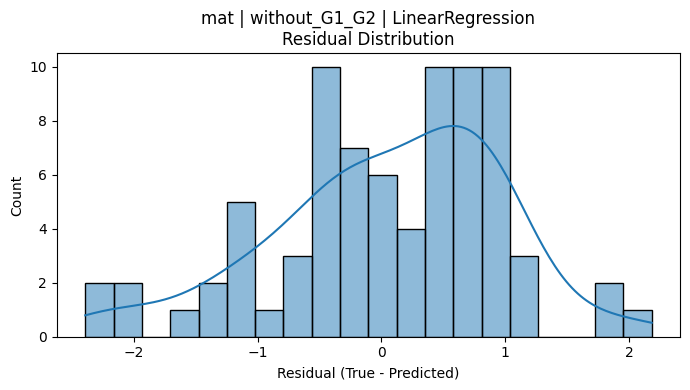

    - Training RandomForestRegressor ...


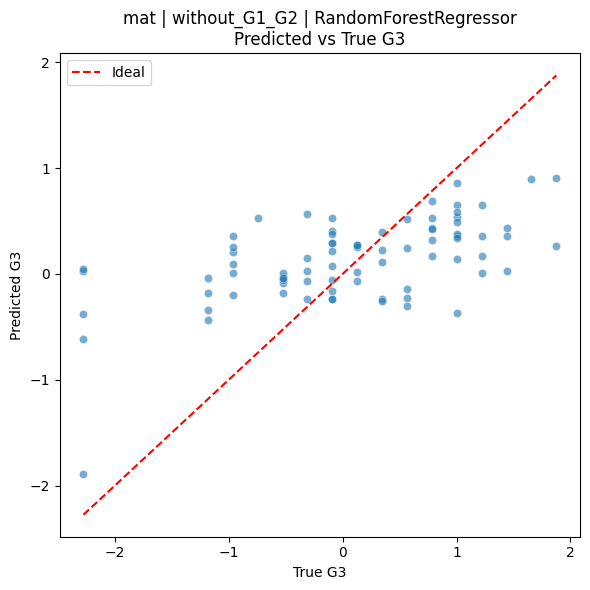

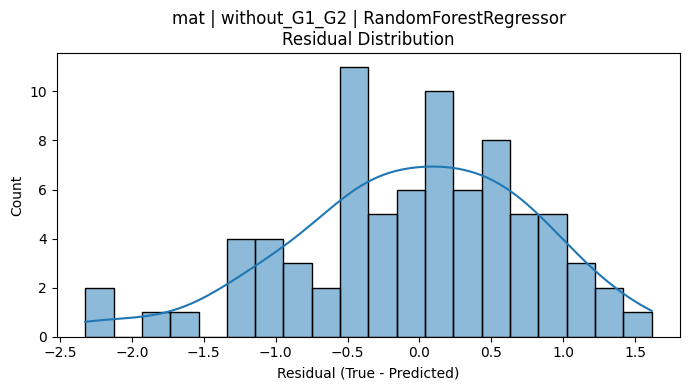

    - Training XGBRegressor ...


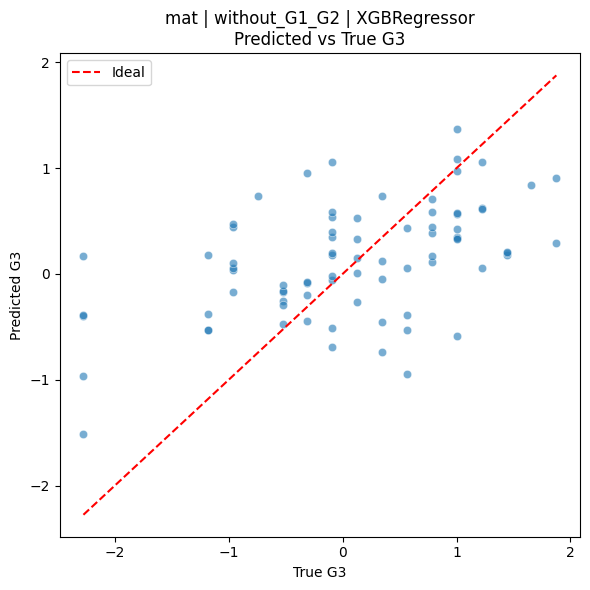

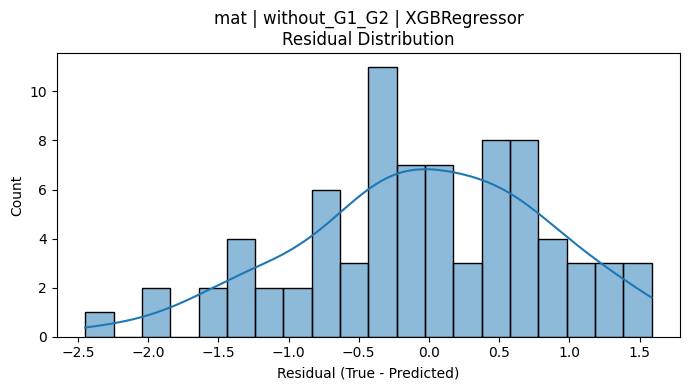


### Dataset: por ###

  > Scenario: with_G1_G2
    - Training LinearRegression ...


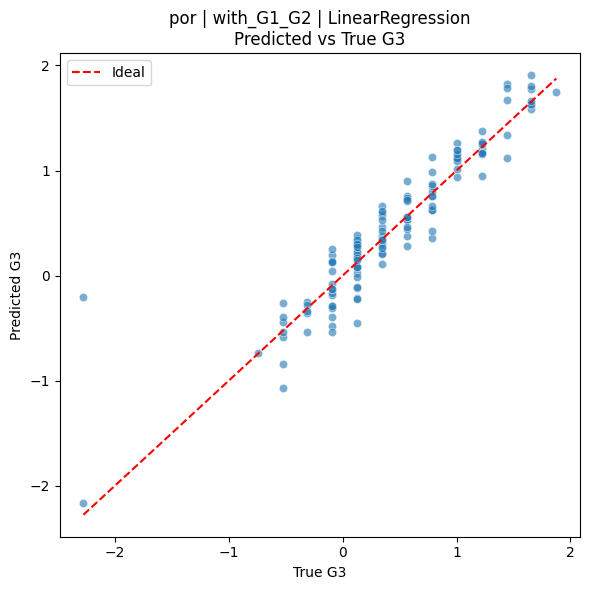

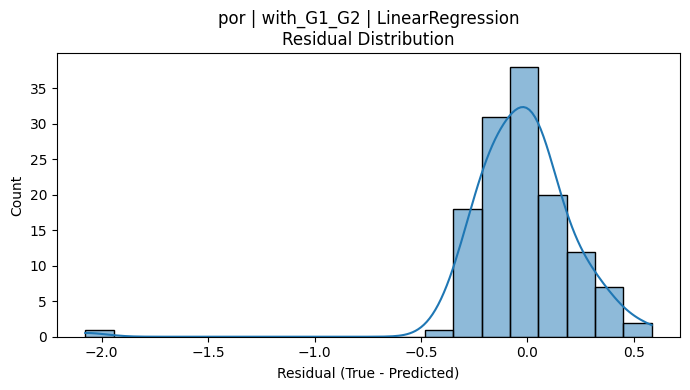

    - Training RandomForestRegressor ...


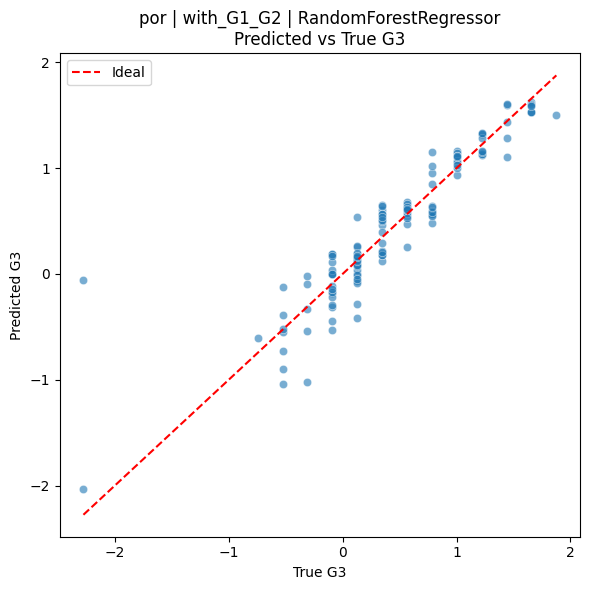

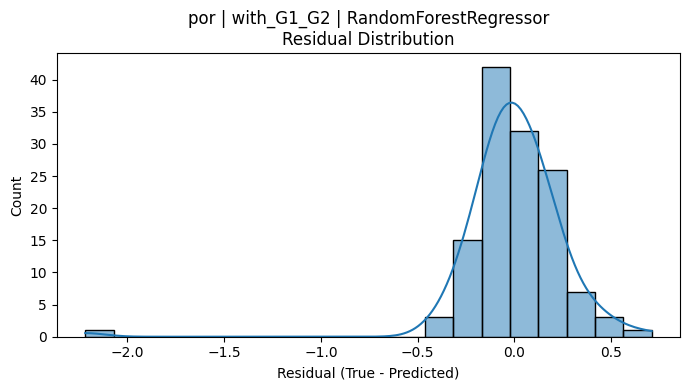

    - Training XGBRegressor ...


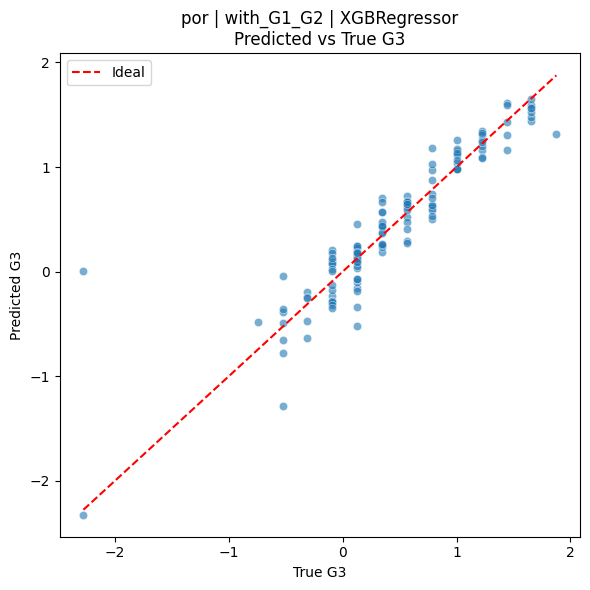

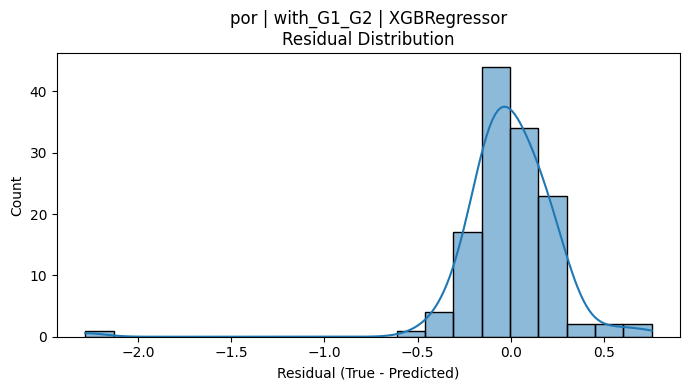


  > Scenario: without_G1_G2
    - Training LinearRegression ...


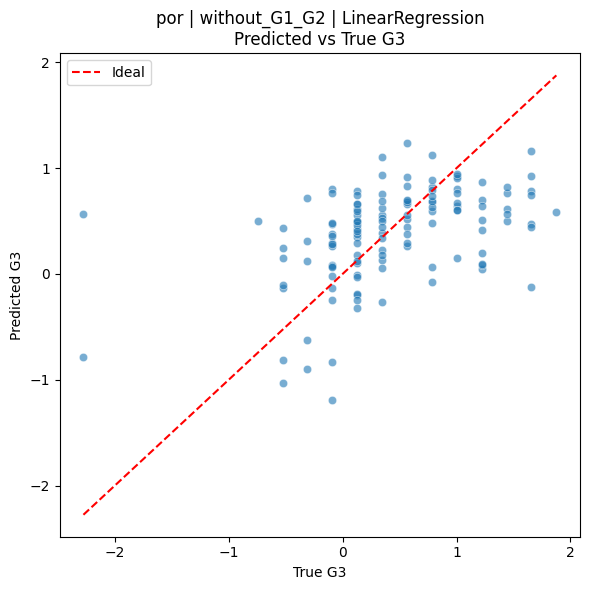

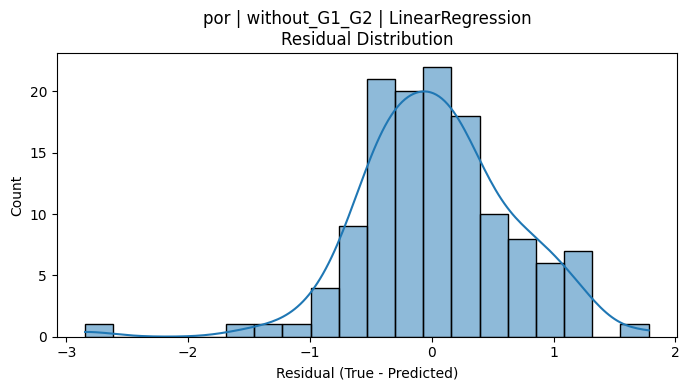

    - Training RandomForestRegressor ...


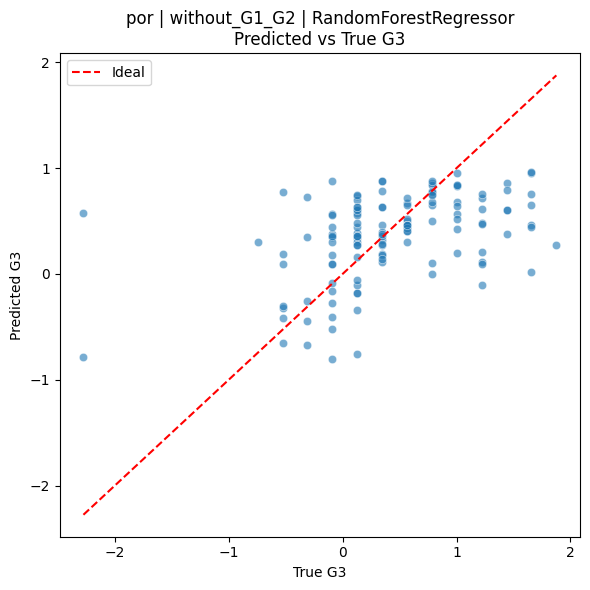

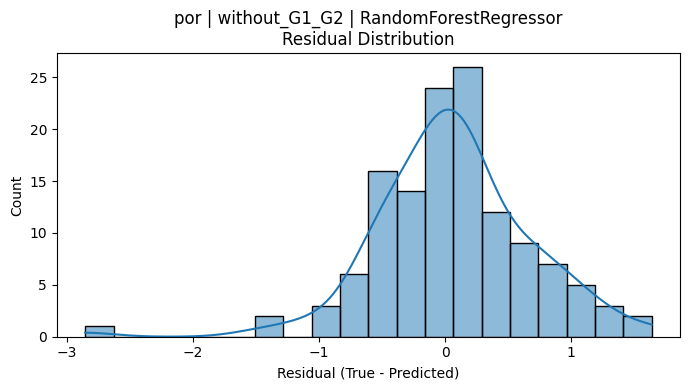

    - Training XGBRegressor ...


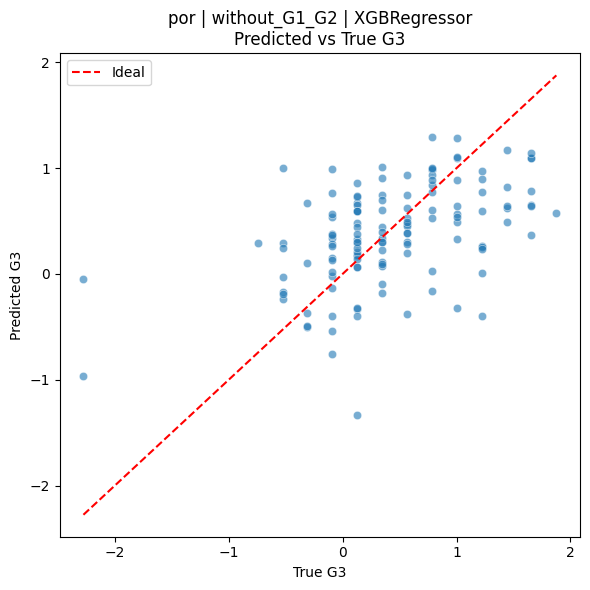

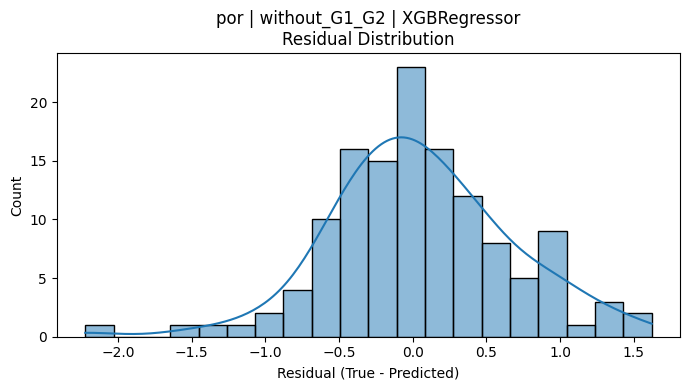


===== Regression Results Summary =====



,dataset,scenario,model,n_features,MAE,RMSE,R2,CV_RMSE_mean,CV_RMSE_std
0,mat,with_G1_G2,LinearRegression,46,0.360,0.520,0.724,0.445,0.082
1,mat,with_G1_G2,RandomForestRegressor,46,0.257,0.431,0.811,0.392,0.063
2,mat,with_G1_G2,XGBRegressor,46,0.275,0.452,0.791,0.405,0.087
3,mat,without_G1_G2,LinearRegression,44,0.742,0.917,0.141,0.971,0.140
4,mat,without_G1_G2,RandomForestRegressor,44,0.657,0.826,0.303,0.906,0.115
5,mat,without_G1_G2,XGBRegressor,44,0.688,0.859,0.246,0.991,0.109
6,por,with_G1_G2,LinearRegression,46,0.167,0.266,0.849,0.294,0.070
7,por,with_G1_G2,RandomForestRegressor,46,0.166,0.275,0.838,0.302,0.073
8,por,with_G1_G2,XGBRegressor,46,0.167,0.279,0.832,0.332,0.095
9,por,without_G1_G2,LinearRegression,44,0.471,0.625,0.160,0.599,0.157


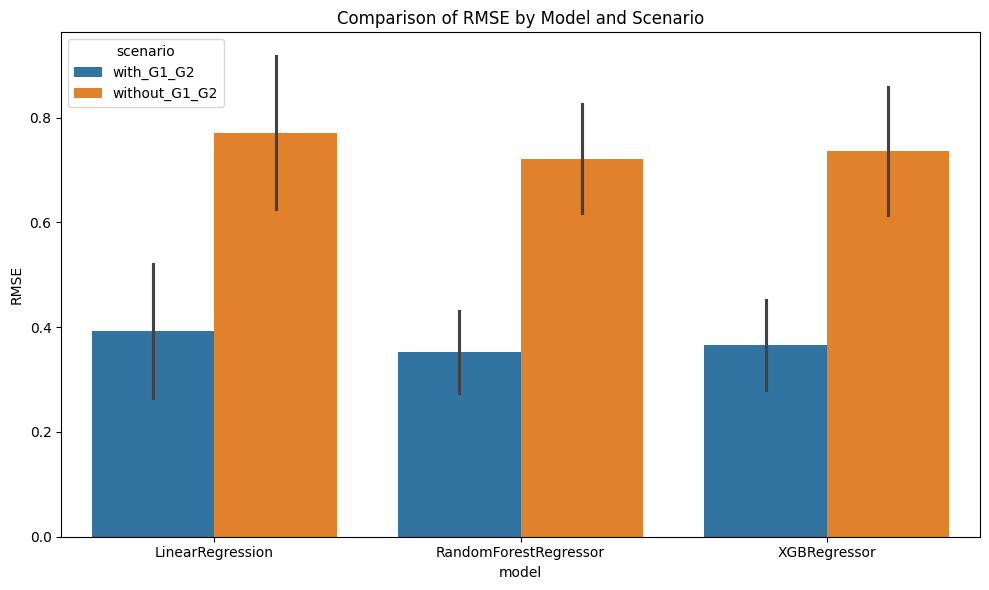

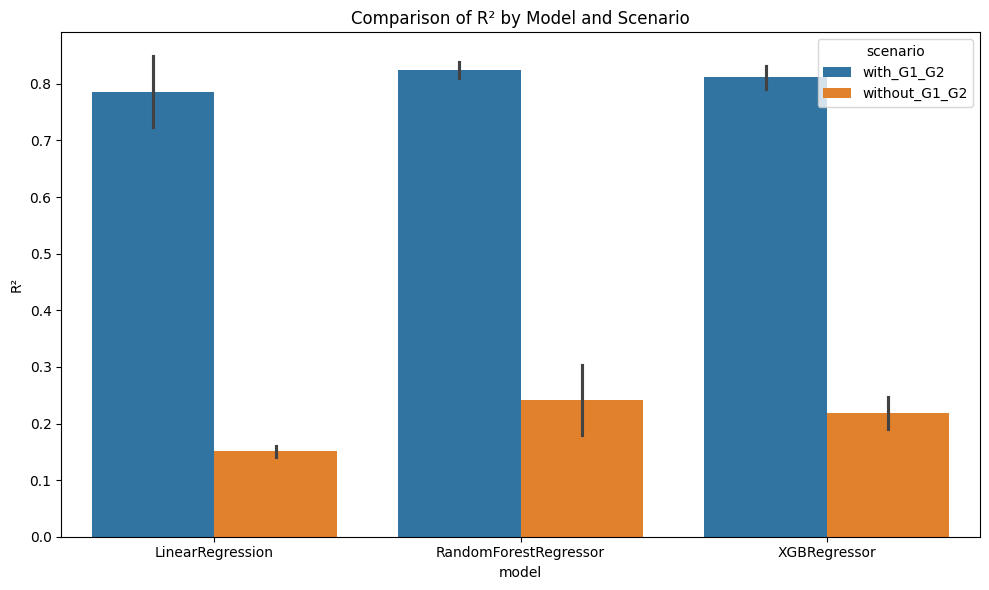

In [10]:
def main() -> None:  # pipeline entrypoint
    models = get_models()  # fetch model dictionary

    datasets = {
        "mat": load_processed("mat"),  # processed math dataset
        "por": load_processed("por"),  # processed Portuguese dataset
    }  # dataset cache

    all_results: List[Dict] = []  # collect run results

    for dataset_name, df in datasets.items():  # iterate datasets
        print(f"\n### Dataset: {dataset_name} ###")  # progress log

        for drop_flag in (False, True):  # iterate scenarios
            scenario_name = "with_G1_G2" if not drop_flag else "without_G1_G2"  # scenario label
            print(f"\n  > Scenario: {scenario_name}")  # log scenario

            for model_name, model in models.items():  # iterate models
                print(f"    - Training {model_name} ...")  # log model
                result = train_single_model(
                    df=df,  # dataset
                    model_name=model_name,  # model name
                    model=model,  # estimator
                    dataset_name=dataset_name,  # dataset tag
                    drop_g1_g2=drop_flag,  # scenario flag
                )  # train/evaluate

                all_results.append(result)  # store result

                plot_predictions_vs_truth(result, PLOTS_DIR)  # save pred vs true plot
                plot_residuals(result, PLOTS_DIR)  # save residual plot

    results_df = pd.DataFrame(all_results)  # aggregate results
    plot_summary_tables_and_charts(results_df, PLOTS_DIR)  # summary outputs


if __name__ == "__main__":  # script entry guard
    main()  # run pipeline
